# 第033讲 下降条件与收敛分析

## Goal
把每条理论结论与其假设、索引和实际数值对象对齐。主例是 f(u,v)=(u²+4v²)/2，初值(2,1)，η=1/4。辅助函数用来区分凸性、全局强凸性、驻点和数值停滞。全部为确定性合成数学实验。

## Setup
先重启内核，再从上到下运行。第一格在任何数字输出前检查两个输入文件的完整字节及全部字段。固定教学数据若被改动，必须停止并同步重写推导，不能沿用旧答案。核心脚本标准库即可，绘图需要NumPy、Matplotlib。

### Key assumptions
全局L光滑、下有界、凸且最优点存在、强凸是四个不同条件。下面有限曲线不证明全域性质。数学定理针对精确迭代；浮点结果必须显示停止原因。

In [1]:
from pathlib import Path
import importlib.util, hashlib, json, math, sys
HERE = Path.cwd()
if not (HERE / 'experiment.py').is_file():
    raise RuntimeError('Run this notebook with its own unit directory as working directory')
spec = importlib.util.spec_from_file_location('unit033_experiment', HERE / 'experiment.py')
e = importlib.util.module_from_spec(spec)
spec.loader.exec_module(e)
data, config = e.check_notebook_baseline()  # Complete bytes and every field before output.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':.18})
print('Default files and complete schema verified; Python', sys.version.split()[0])

Default files and complete schema verified; Python 3.12.14


## Steps
### 1 三次前向和两次更新
平方、各分支贡献、总目标、局部链式导数组成的梯度，均用当前参数重新计算。读完下列三状态再画曲线：t=0目标4，t=1为9/8，t=2为81/128。

In [2]:
report = e.compile_report(data, config)
main = report['quadratic']['history']
for s in main[:3]:
    print('t =', s['iteration'], 'w =', s['w'], 'squares =', s['squares'])
    print('contributions =', s['loss_contributions'], 'f =', s['value'])
    print('local derivatives =',s['local_derivatives'])
    print('gradient =', s['gradient'], 'gradient^2 =', s['gradient_squared'])
    print('distance^2 =', s['distance_squared'], 'next update =', s.get('update'))
    if 'descent_upper' in s:
        print('next objective upper =', s['descent_upper'], 'slack =', s['descent_slack'])

t = 0 w = [2.0, 1.0] squares = [4.0, 1.0]
contributions = [2.0, 2.0] f = 4.0
local derivatives = {'square_wrt_coordinate': [4.0, 2.0], 'contribution_wrt_square': [0.5, 2.0], 'sum_wrt_contribution': [1.0, 1.0]}
gradient = [2.0, 4.0] gradient^2 = 20.0
distance^2 = 5.0 next update = [-0.5, -1.0]
next objective upper = 1.5 slack = 0.375
t = 1 w = [1.5, 0.0] squares = [2.25, 0.0]
contributions = [1.125, 0.0] f = 1.125
local derivatives = {'square_wrt_coordinate': [3.0, 0.0], 'contribution_wrt_square': [0.5, 2.0], 'sum_wrt_contribution': [1.0, 1.0]}
gradient = [1.5, 0.0] gradient^2 = 2.25
distance^2 = 2.25 next update = [-0.375, -0.0]
next objective upper = 0.84375 slack = 0.2109375
t = 2 w = [1.125, 0.0] squares = [1.265625, 0.0]
contributions = [0.6328125, 0.0] f = 0.6328125
local derivatives = {'square_wrt_coordinate': [2.25, 0.0], 'contribution_wrt_square': [0.5, 2.0], 'sum_wrt_contribution': [1.0, 1.0]}
gradient = [1.125, 0.0] gradient^2 = 1.265625
distance^2 = 1.265625 next update = [-

### 2 用独立分数算术复算
分数对象从精确整数和1/4构建；先计算自己的轨迹，再检查浮点结果。后期乘法可能舍入，所以完整路径比较用相对尺度，零参照则单独处理。

In [3]:
from fractions import Fraction as F
w = [F(2), F(1)]
q = [F(1), F(4)]
eta = F(1,4)
for t, s in enumerate(main):
    f_ref = sum(a*x*x/2 for a,x in zip(q,w))
    g_ref = [a*x for a,x in zip(q,w)]
    if not math.isclose(s['value'], float(f_ref), rel_tol=5e-13, abs_tol=0):
        raise RuntimeError('Independent full-path fraction mismatch')
    if t < 3:
        print('exact t',t,'w',[str(x) for x in w],'f',str(f_ref),'g',[str(x) for x in g_ref])
    w = [(1-eta*a)*x for a,x in zip(q,w)]
print('All', len(main), 'quadratic states checked against independent Fraction trajectory')

exact t 0 w ['2', '1'] f 4 g ['2', '4']
exact t 1 w ['3/2', '0'] f 9/8 g ['3/2', '0']
exact t 2 w ['9/8', '0'] f 81/128 g ['9/8', '0']
All 41 quadratic states checked against independent Fraction trajectory


### 3 三种量不能混为一种误差
目标差、梯度平方和参数距离平方的单位不同。这里只因最优值和参数恰好是0，value才直接等于目标差。下面没有人为给非零小量加显示地板。

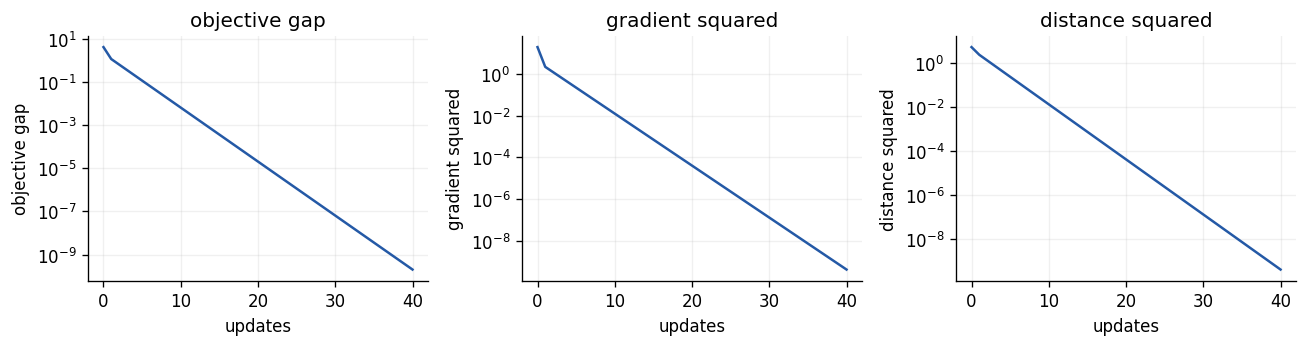

In [4]:
t = np.array([s['iteration'] for s in main])
fig, axes = plt.subplots(1,3,figsize=(11,3))
for ax,key,title in zip(axes,['value','gradient_squared','distance_squared'],
                         ['objective gap','gradient squared','distance squared']):
    ax.semilogy(t,[s[key] for s in main],color='#2459a6')
    ax.set(xlabel='updates',ylabel=title,title=title)
fig.tight_layout(); plt.show()

### 4 同一实际目标曲线 两个不同上界
对T≥1，凸界10/T；强凸界4(3/4)^T。更快的实际下降不否定上界，也不能单独证明某个全局强凸常数。

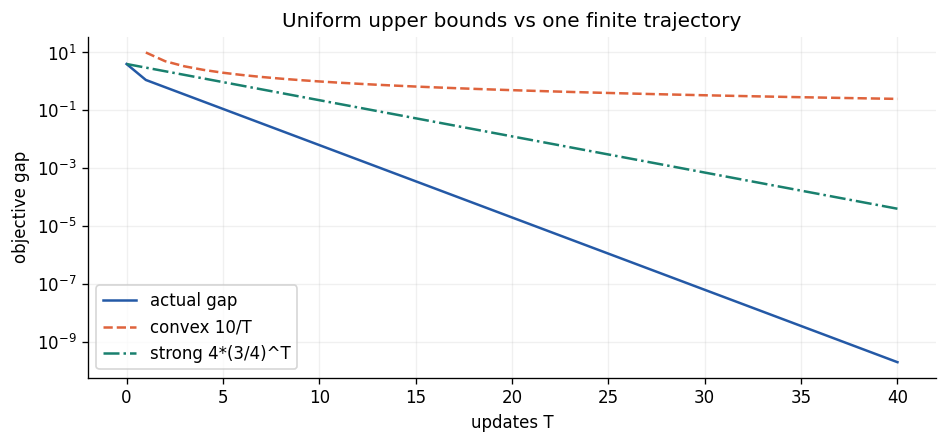

In [5]:
fig, ax = plt.subplots(figsize=(8,3.8))
ax.semilogy(t,[s['value'] for s in main],label='actual gap',color='#2459a6')
ax.semilogy(t[1:],[s['convex_bound'] for s in main[1:]],'--',label='convex 10/T',color='#df633c')
ax.semilogy(t,[s['strong_bound'] for s in main],'-.',label='strong 4*(3/4)^T',color='#19806e')
ax.set(xlabel='updates T',ylabel='objective gap',title='Uniform upper bounds vs one finite trajectory')
ax.legend(); fig.tight_layout(); plt.show()

### 5 前T个梯度平方的最小值
索引是0到T−1，不能不说明就改成最终T。T=0必须没有1/T界。主例该界为32/T，和目标差10/T控制不同对象。

T 1 indices 0..0 min g^2 20.0 bound 32.0
T 2 indices 0..1 min g^2 2.25 bound 16.0
T 40 indices 0..39 min g^2 7.191815474721242e-10 bound 0.8


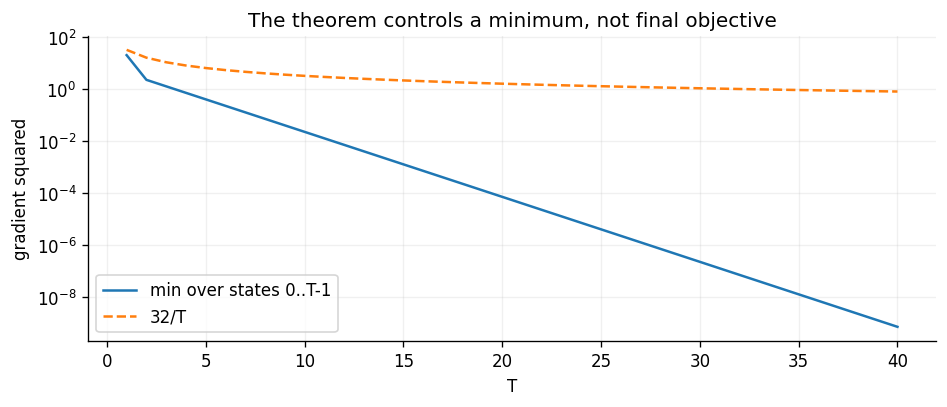

In [6]:
for T in (1,2,40):
    independently_min = min(s['gradient_squared'] for s in main[:T])
    if independently_min != main[T]['minimum_gradient_squared_before_T']:
        raise RuntimeError('Gradient index mismatch')
    print('T',T,'indices',f'0..{T-1}','min g^2',independently_min,'bound',main[T]['nonconvex_gradient_bound'])
if main[0]['convex_bound'] is not None or main[0]['nonconvex_gradient_bound'] is not None:
    raise RuntimeError('T=0 bound must be absent')
fig, ax = plt.subplots(figsize=(8,3.5))
ax.semilogy(t[1:],[s['minimum_gradient_squared_before_T'] for s in main[1:]],label='min over states 0..T-1')
ax.semilogy(t[1:],[s['nonconvex_gradient_bound'] for s in main[1:]],'--',label='32/T')
ax.set(xlabel='T',ylabel='gradient squared',title='The theorem controls a minimum, not final objective')
ax.legend(); fig.tight_layout(); plt.show()

### 6 根号函数的高精度独立检查
h=w²/(sqrt(1+w²)+1)，梯度w/sqrt(1+w²)。500位Decimal在实际存储的每个w处独立求值，也检查完整高精度递推。默认最后一条有效状态为t=9，下一非零更新超出binary64范围，不伪造0。

In [7]:
from decimal import Decimal as D, localcontext
convex = report['convex']
with localcontext() as context:
    context.prec = 500
    w_reference = D(4)
    for s in convex['history']:
        w_stored = D.from_float(s['w'])
        root = (1 + w_stored*w_stored).sqrt()
        value = w_stored*w_stored/(root+1)
        if not math.isclose(s['value'],float(value),rel_tol=5e-15,abs_tol=0):
            raise RuntimeError('Decimal objective mismatch')
        if not math.isclose(s['w'],float(w_reference),rel_tol=3e-11,abs_tol=0):
            raise RuntimeError('Decimal full path mismatch')
        root_reference = (1+w_reference*w_reference).sqrt()
        w_reference = w_reference**3/(root_reference*(root_reference+1))
print(convex['status'], 'completed',convex['updates_completed'])
print('last w',convex['history'][-1]['w'],'last h',convex['history'][-1]['value'])
print('true next positive w in high precision',format(w_reference,'.8E'))
print('direct vs stable upper at t=7:',convex['history'][7]['descent_upper_naive_diagnostic'],convex['history'][7]['descent_upper'])

numeric_range_limit completed 9
last w 7.076579218491313e-134 last h 2.503898671779156e-267
true next positive w in high precision 1.77190373E-400
direct vs stable upper at t=7: 0.0 8.537671205740814e-60


### 7 稳定值 极快局部下降 和有限数值范围
没有全局正μ，因为h″=(1+w²)^(-3/2)在远处趋0。实际局部快曲线不能推翻这一解析事实。图中只画执行过的状态，不把剩余预算补成零。

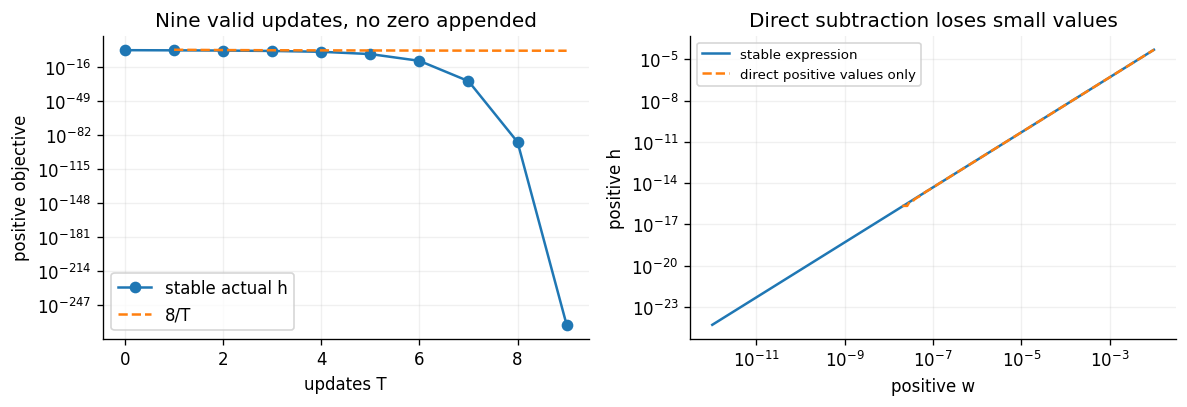

In [8]:
p = convex['history']; tc = [s['iteration'] for s in p]
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].semilogy(tc,[s['value'] for s in p],'o-',label='stable actual h')
axes[0].semilogy(tc[1:],[s['convex_bound'] for s in p[1:]],'--',label='8/T')
axes[0].set(xlabel='updates T',ylabel='positive objective',title='Nine valid updates, no zero appended'); axes[0].legend()
x = np.logspace(-12,-2,180)
stable = x*x/(np.hypot(1,x)+1)
direct = np.sqrt(1+x*x)-1
axes[1].loglog(x,stable,label='stable expression')
keep = direct>0
axes[1].loglog(x[keep],direct[keep],'--',label='direct positive values only')
axes[1].set(xlabel='positive w',ylabel='positive h',title='Direct subtraction loses small values'); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 8 同一非凸函数的两个初值
零初值是精确驻点最大值；另一条轨迹最终舍入停滞。math.pi是存储近似，不能因为到该数的距离为0，就宣称到数学最优点距离精确0。

initial 0.0 status exact_stationary_in_implemented_model updates 0
final objective 2.0 gradient -0.0
initial 1.0 status floating_stagnation updates 5
final objective 7.498798913309288e-33 gradient -1.2246467991473532e-16


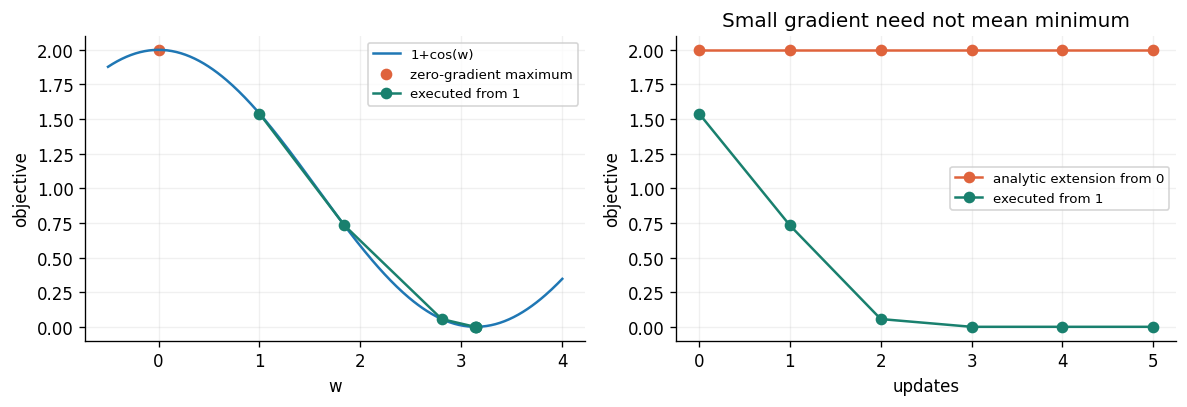

In [9]:
nonconvex = report['nonconvex']
for p in nonconvex:
    print('initial',p['history'][0]['w'],'status',p['status'],'updates',p['updates_completed'])
    print('final objective',p['history'][-1]['value'],'gradient',p['history'][-1]['gradient'])
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
x = np.linspace(-.5,4,300)
axes[0].plot(x,1+np.cos(x),label='1+cos(w)')
axes[0].scatter([0],[2],color='#df633c',label='zero-gradient maximum')
p = nonconvex[1]['history']
axes[0].plot([s['w'] for s in p],[s['value'] for s in p],'o-',color='#19806e',label='executed from 1')
axes[0].set(xlabel='w',ylabel='objective'); axes[0].legend(fontsize=8)
axes[1].plot(range(6),[2]*6,'o-',color='#df633c',label='analytic extension from 0')
axes[1].plot([s['iteration'] for s in p],[s['value'] for s in p],'o-',color='#19806e',label='executed from 1')
axes[1].set(xlabel='updates',ylabel='objective',title='Small gradient need not mean minimum'); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 9 正数声称与真实证书不同
L=1和μ=2是故意保留的错误声称。它们必须带assumptions_false标签，不能把输入合法误当定理成立。条形图在每个选定反例点比较真实值和声称界。

L 4.0 valid_global_hessian_certificate x [0.0, 0.0] y [0.0, 1.0]
L 8.0 valid_global_hessian_certificate x [0.0, 0.0] y [0.0, 1.0]
L 1.0 assumptions_false_counterexample x [0.0, 0.0] y [0.0, 1.0]
mu 1.0 valid_global_hessian_certificate x [0.0, 0.0] y [1.0, 0.0]
mu 0.5 valid_global_hessian_certificate x [0.0, 0.0] y [1.0, 0.0]
mu 2.0 assumptions_false_counterexample x [0.0, 0.0] y [1.0, 0.0]


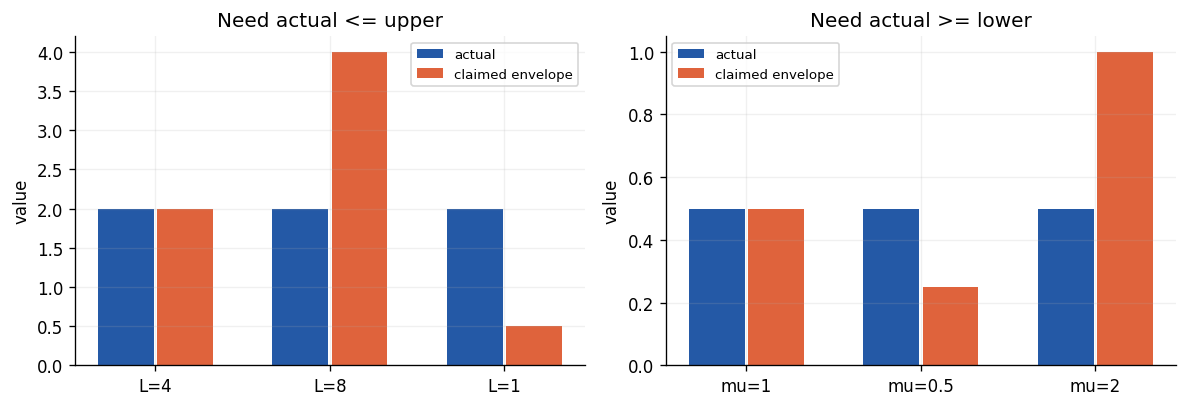

In [10]:
for kind, cases in report['certificates'].items():
    for c in cases:
        print(kind,c['claim'],c['label'],'x',c['x'],'y',c['y'])
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
for ax,kind,key,title in [(axes[0],'L','proposed_upper','Need actual <= upper'),
                        (axes[1],'mu','proposed_lower','Need actual >= lower')]:
    cases=report['certificates'][kind]; positions=np.arange(3)
    ax.bar(positions-.17,[c['actual_value'] for c in cases],.32,label='actual',color='#2459a6')
    ax.bar(positions+.17,[c[key] for c in cases],.32,label='claimed envelope',color='#df633c')
    ax.set(xticks=positions,xticklabels=[f"{kind}={c['claim']:g}" for c in cases],ylabel='value',title=title)
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

### 10 步长越界的完整机制
高曲率方向倍率为1−4η。η=1/2只是不增保证的边界，出现两周期；η=3/4损失每轮乘4。这些路径不输出本讲较小步长下的凸/强凸界。

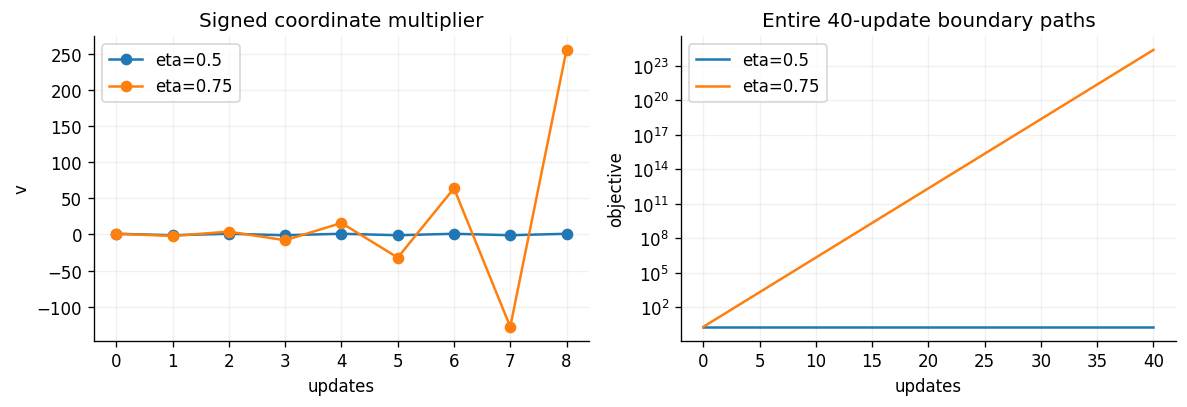

In [11]:
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
for p in report['boundary']:
    shown=p['history'][:9]
    axes[0].plot([s['iteration'] for s in shown],[s['w'][1] for s in shown],'o-',label=f"eta={p['eta']:g}")
    axes[1].semilogy([s['iteration'] for s in p['history']],[s['value'] for s in p['history']],label=f"eta={p['eta']:g}")
    if any(s['convex_bound'] is not None or s['strong_bound'] is not None for s in p['history']):
        raise RuntimeError('Unsafe rate received a safe-rate bound')
axes[0].set(xlabel='updates',ylabel='v',title='Signed coordinate multiplier')
axes[1].set(xlabel='updates',ylabel='objective',title='Entire 40-update boundary paths')
for ax in axes: ax.legend()
fig.tight_layout(); plt.show()

### 11 理论预算与观测到的首次达标
一般几何预算53与指数松预算61均为充分条件，实际有限路径第26步已达标。也检查初始达标和ρ=0的一步情形，不对log0作计算。

actual first target update: 26
sufficient budgets: {'geometric_sufficient': 53, 'exponential_sufficient': 61, 'factor': 0.75}
already optimal: {'geometric_sufficient': 0, 'exponential_sufficient': 0, 'factor': 0.75}
mu=L and eta=1/L: {'geometric_sufficient': 1, 'exponential_sufficient': 16, 'factor': 0.0}


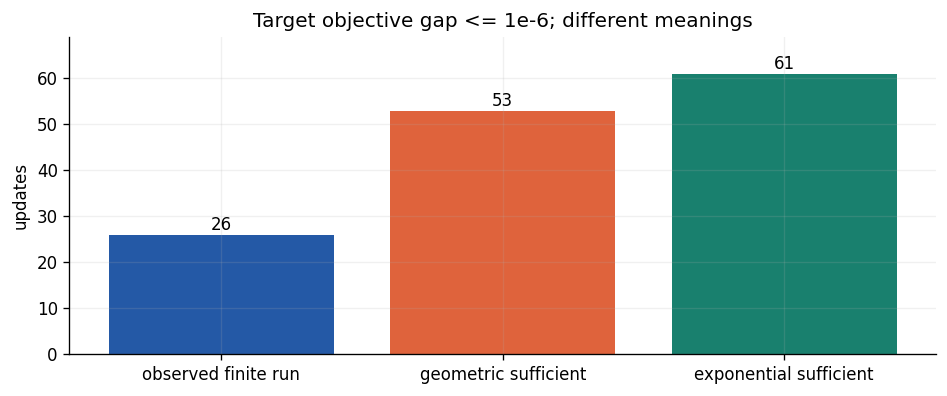

In [12]:
print('actual first target update:',report['first_observed_target_update'])
print('sufficient budgets:',report['budget'])
print('already optimal:',e.strong_budget(0,1e-6,.25,1,4))
print('mu=L and eta=1/L:',e.strong_budget(4,1e-6,.25,4,4))
counts=[report['first_observed_target_update'],report['budget']['geometric_sufficient'],report['budget']['exponential_sufficient']]
fig, ax=plt.subplots(figsize=(8,3.4))
ax.bar(['observed finite run','geometric sufficient','exponential sufficient'],counts,color=['#2459a6','#df633c','#19806e'])
for i,v in enumerate(counts): ax.text(i,v+1,str(v),ha='center')
ax.set(ylabel='updates',ylim=(0,69),title='Target objective gap <= 1e-6; different meanings')
fig.tight_layout(); plt.show()

## Checks
### 12 非法尾字段先于任何迭代被拒绝
下列检查不创建外部文件。bool和complex不能先转换后混入有效实数；未展示的最后一个字段也必须先验证。

In [13]:
import copy
for field,value in [('boundary_rates',[.5,True]),('nonconvex_initials',[0,complex(1,0)]),('target_gap',float('nan'))]:
    changed=copy.deepcopy(config); changed[field]=value
    try:
        e.compile_report(data,changed)
    except ValueError as error:
        print('rejected before report:',field,str(error))
    else:
        raise RuntimeError('Bad input was accepted')
try:
    json.loads('{"steps":0,"steps":1}',object_pairs_hook=e.unique_object)
except ValueError as error:
    print('duplicate key rejected:',str(error))
else:
    raise RuntimeError('Duplicate key accepted')

rejected before report: boundary_rates boundary_rates[1] requires a built-in int or float, not bool/complex/extended scalar
rejected before report: nonconvex_initials nonconvex_initials[1] requires a built-in int or float, not bool/complex/extended scalar
rejected before report: target_gap target_gap outside supported finite range
duplicate key rejected: duplicate JSON key: steps


### 13 完整报告一致性
下面比较整份JSON字节，不只是几个摘要数。Notebook没有偷偷换数据，也没有调用预存图片代替实际画图。若脚本输出文件被更新而Notebook未重跑，这里会明确失败。

In [14]:
payload=e.report_bytes(report)
if payload != (HERE/'outputs/report.json').read_bytes():
    raise RuntimeError('Complete notebook report differs from delivered script JSON')
print('full report SHA256:',hashlib.sha256(payload).hexdigest())
print('all report bytes match; states:',len(main),'convex:',len(convex['history']),
      'nonconvex:',[len(p['history']) for p in nonconvex])

full report SHA256: 8365b4e5e58d7ee80333de1d1bfbceb865bc3a0c58caa822e8e7c976290ec82c
all report bytes match; states: 41 convex: 10 nonconvex: [1, 6]


## Next Steps
重述三条定理的全部假设、受控量和索引。解释数值范围限制、舍入停滞与零梯度最大点为什么是不同结论。再读answers.pdf复核18题，尤其是完整积分余项、距离势能相消、强凸配方及错误L/μ反例。

所有图是本次执行计算出的8个PNG输出。当前环境验证了新Python进程中的真实InProcessKernel顺序执行，没有测试浏览器Jupyter界面、Anaconda环境创建或socket传输。独立审核使用70组Fraction完整轨迹、500位Decimal根号参照和160位Taylor三角参照；有限数值一致性不替代全局证明。

资料与核查范围见source-checks.json；主要一手资料为[Boyd与Vandenberghe课件](https://web.stanford.edu/class/ee364a/lectures/unconstrained.pdf)、[Cornell CS4787 Lecture5](https://www.cs.cornell.edu/courses/cs4787/2025fa/lectures/lecture5.html)与Python官方文档。